# PMHRD — Parallelized Mental Health Risk Detection
**PDC + NLP Final Phase | NUCES Islamabad | DS-A**

> **Areeba Arshad (23i-2656) | Hadia Khawar (23i-0106)**

This notebook runs the complete 6-stage PMHRD pipeline:
1. Dataset Construction & Label Mapping
2. Parallel Text Preprocessing (`multiprocessing`)
3. Parallel Tokenization (`concurrent.futures`)
4. MentalBERT Fine-Tuning with LoRA + FP16 + Safety-Aware Loss
5. Parallel Batch Inference Benchmarking
6. Safety-Aware Evaluation (Macro-F1, FNR, Risk-Sensitive F1, PDC speedups)

---
**Before running:** Go to `Runtime → Change runtime type → T4 GPU`


## Step 1 — Verify GPU

In [ ]:
import torch, platform, subprocess

print("=== Runtime Info ===")
print(f"Python : {platform.python_version()}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA   : {torch.version.cuda}")
print(f"GPU    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NOT AVAILABLE'}")
print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB" if torch.cuda.is_available() else "")

if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected! Go to Runtime → Change runtime type → T4 GPU")
print("\nGPU ready!")


=== Runtime Info ===
Python : 3.12.13
PyTorch: 2.10.0+cu128
CUDA   : 12.8
GPU    : Tesla T4
VRAM   : 14.6 GB

GPU ready!


## Step 2 — Install Dependencies

In [ ]:
%%capture
!pip install transformers==4.40.0 scikit-learn pandas numpy tqdm
print("Dependencies installed")


## Step 3 — Create Project Structure

In [ ]:
import os

DIRS = ["pmhrd/stages", "pmhrd/data", "pmhrd/model", "pmhrd/outputs"]
for d in DIRS:
    os.makedirs(d, exist_ok=True)

print("Project structure:")
for d in DIRS:
    print(f"  {d}/")
print("\nDirectories created")


Project structure:
  pmhrd/stages/
  pmhrd/data/
  pmhrd/model/
  pmhrd/outputs/

Directories created


## Step 4 — Write Source Files
*(Run once — writes all pipeline stages to disk)*

In [ ]:
# ── stages/__init__.py ──────────────────────────────────────────────────────
with open("pmhrd/stages/__init__.py", "w") as f:
    f.write("# PMHRD stages\n")
print("✓ __init__.py")


✓ __init__.py


In [ ]:
%%writefile pmhrd/stages/stage1_data.py
"""
Stage 1: Dataset Construction & Label Mapping

FIXES (v3):
- PRIMARY test set is now a held-out 10% split of DS1+DS2 corpus, which
  contains all 4 classes in realistic proportions. This is the main eval set.
- DS3 (Depression Reddit Cleaned) is kept as a SECONDARY binary test to
  validate depression detection specifically — matching its binary nature.
- Both train/val/test splits are stratified to preserve class balance.
- max_len raised to 256 in config for better long-post coverage.
"""
import os, glob, re, html
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

DS1_LABEL_MAP = {
    "normal": 0, "anxiety": 1, "stress": 1,
    "bipolar": 2, "personality disorder": 2, "suicidal": 3,
}
SEVERE_KEYWORDS = [
    r"\bsevere\b", r"\bworst\b", r"\bcan'?t go on\b", r"\bgive up\b",
    r"\bno hope\b", r"\bhopeless\b", r"\bnumb\b", r"\bworthless\b",
    r"\bno purpose\b", r"\bsuicid\b", r"\bend (my|it all)\b",
    r"\bkill myself\b", r"\bwant to die\b", r"\bempty inside\b",
    r"\bexhausted of living\b", r"\bcan't function\b",
]
SELF_HARM_KEYWORDS = [
    r"\bsuicid\b", r"\bkill myself\b", r"\bend (my life|it all)\b",
    r"\bself.?harm\b", r"\bcutting\b", r"\boverdose\b",
    r"\bwant to die\b", r"\bno reason to live\b", r"\bhurt myself\b",
]

def _score(text, patterns):
    text = str(text).lower()
    return sum(1 for p in patterns if re.search(p, text))

def _map_ds1(row):
    label = str(row["label"]).strip().lower()
    if label in DS1_LABEL_MAP:
        return DS1_LABEL_MAP[label]
    if label == "depression":
        s = _score(row["text"], SEVERE_KEYWORDS)
        return 2 if s >= 3 else 1
    return -1

def _load_ds1(data_dir):
    paths = (glob.glob(f"{data_dir}/Combined Data.csv") +
             glob.glob(f"{data_dir}/dataset1*.csv") +
             glob.glob(f"{data_dir}/mental_health*.csv") +
             glob.glob(f"{data_dir}/sentiment_mental*.csv"))
    if not paths:
        raise FileNotFoundError("Dataset 1 not found. Rename to dataset1.csv")
    df = pd.read_csv(paths[0])
    df.columns = [c.strip().lower() for c in df.columns]
    tc = next((c for c in df.columns if c in ("statement","text","post")), None)
    lc = next((c for c in df.columns if c in ("status","label","category")), None)
    if not tc or not lc:
        raise ValueError(f"DS1 columns not recognised: {df.columns.tolist()}")
    df = df.rename(columns={tc:"text", lc:"label"})[["text","label"]].dropna()
    df["label"] = df.apply(_map_ds1, axis=1)
    df = df[df["label"] >= 0]
    print(f"  DS1 loaded: {len(df):,} samples")
    return df[["text","label"]]

def _load_ds2(data_dir):
    paths = (glob.glob(f"{data_dir}/dataset2*.csv") +
             glob.glob(f"{data_dir}/mental_health_corpus*.csv") +
             glob.glob(f"{data_dir}/*corpus*.csv"))
    if not paths:
        raise FileNotFoundError("Dataset 2 not found. Rename to dataset2.csv")
    df = pd.read_csv(paths[0])
    df.columns = [c.strip().lower() for c in df.columns]
    tc = next((c for c in df.columns if c in ("text","post","statement")), None)
    lc = next((c for c in df.columns if c in ("label","toxic","target","class")), None)
    if not tc or not lc:
        raise ValueError(f"DS2 columns not recognised: {df.columns.tolist()}")
    df = df.rename(columns={tc:"text", lc:"raw_label"})[["text","raw_label"]].dropna()
    def _m2(row):
        raw = str(row["raw_label"]).strip().lower()
        if raw not in ("1","toxic","true","yes"): return 0
        return 3 if _score(row["text"], SELF_HARM_KEYWORDS) >= 1 else 2
    df["label"] = df.apply(_m2, axis=1)
    print(f"  DS2 loaded: {len(df):,} samples")
    return df[["text","label"]]

def _load_ds3_binary(data_dir):
    """Load DS3 as a binary secondary test set (depressed vs not)."""
    paths = (glob.glob(f"{data_dir}/dataset3*.csv") +
             glob.glob(f"{data_dir}/depression_dataset_reddit*.csv") +
             glob.glob(f"{data_dir}/*reddit*clean*.csv") +
             glob.glob(f"{data_dir}/*depression*reddit*.csv"))
    if not paths:
        raise FileNotFoundError("Dataset 3 not found. Rename to dataset3.csv")
    df = pd.read_csv(paths[0])
    df.columns = [c.strip().lower() for c in df.columns]
    tc = next((c for c in df.columns if "text" in c or "post" in c), None)
    lc = next((c for c in df.columns if "label" in c or "depression" in c or "class" in c), None)
    if not tc or not lc:
        raise ValueError(f"DS3 columns not recognised: {df.columns.tolist()}")
    df = df.rename(columns={tc:"text", lc:"raw_label"})[["text","raw_label"]].dropna()
    # Keep as binary: 1 = any depression risk (maps to 1 or 2), 0 = no risk
    def _m3(row):
        raw = str(row["raw_label"]).strip()
        if raw in ("1","depressed","depression","true"):
            return 2 if _score(row["text"], SEVERE_KEYWORDS) >= 3 else 1
        return 0
    df["label"] = df.apply(_m3, axis=1)
    print(f"  DS3 loaded: {len(df):,} samples (secondary binary test)")
    return df[["text","label"]]

def load_and_map_datasets(data_dir="pmhrd/data", seed=42):
    print(f"Loading datasets from {data_dir}/...")
    df1 = _load_ds1(data_dir)
    df2 = _load_ds2(data_dir)
    df3 = _load_ds3_binary(data_dir)

    # Combine DS1 + DS2 as the full labelled corpus
    df_all = pd.concat([df1, df2], ignore_index=True).drop_duplicates(subset=["text"]).dropna()
    df_all["text"]  = df_all["text"].astype(str)
    df_all["label"] = df_all["label"].astype(int)

    print(f"\n  Combined corpus: {len(df_all):,} samples")
    names = ["No Risk","Mild Dep.","Mod/Severe Dep.","Self-Harm"]
    for c, n in enumerate(names):
        cnt = (df_all["label"]==c).sum()
        print(f"    Class {c} ({n}): {cnt:,} ({100*cnt/len(df_all):.1f}%)")

    # FIX: 80/10/10 stratified split — primary test from same distribution as train
    df_trainval, df_test = train_test_split(
        df_all, test_size=0.10, random_state=seed, stratify=df_all["label"])
    df_train, df_val = train_test_split(
        df_trainval, test_size=0.111, random_state=seed, stratify=df_trainval["label"])
    # 0.111 of 90% ≈ 10% of total → final split ~80/10/10

    print(f"\n  Train: {len(df_train):,} | Val: {len(df_val):,} | Primary Test: {len(df_test):,}")
    print(f"  Secondary Test (DS3 binary): {len(df3):,}")

    # Verify test set has all 4 classes
    test_classes = df_test["label"].unique()
    print(f"  Primary test classes present: {sorted(test_classes.tolist())}")

    return (df_train.reset_index(drop=True),
            df_val.reset_index(drop=True),
            df_test.reset_index(drop=True),
            df3.reset_index(drop=True))


Writing pmhrd/stages/stage1_data.py


In [ ]:
%%writefile pmhrd/stages/stage2_preprocess.py
"""Stage 2: Parallelized Text Preprocessing using multiprocessing.Pool"""
import os, re, time, html, multiprocessing
import numpy as np
import pandas as pd

def _clean_text(text):
    if not isinstance(text, str): text = str(text)
    text = html.unescape(text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", "[USER]", text)
    text = re.sub(r"r/\w+", "[SUBREDDIT]", text)
    text = re.sub(r"[^\x00-\x7F]+", " ", text)
    text = re.sub(r"([!?.,-])\1{2,}", r"\1", text)
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text

def _clean_chunk(texts):
    return [_clean_text(t) for t in texts]

def _sequential_clean(texts):
    return [_clean_text(t) for t in texts]

def _parallel_clean(texts, num_workers):
    chunks = [list(c) for c in np.array_split(texts, num_workers) if len(c) > 0]
    with multiprocessing.Pool(processes=num_workers) as pool:
        results = pool.map(_clean_chunk, chunks)
    return [t for chunk in results for t in chunk]

def _benchmark(texts, num_workers, output_dir):
    sample = texts[:5000]
    print(f"  Benchmarking preprocessing: {len(sample):,} samples, {num_workers} workers...")
    t0 = time.perf_counter(); _sequential_clean(sample); t_seq = time.perf_counter()-t0
    t0 = time.perf_counter(); _parallel_clean(sample, num_workers); t_par = time.perf_counter()-t0
    speedup = t_seq/t_par if t_par>0 else 0
    print(f"  Sequential: {t_seq:.3f}s | Parallel: {t_par:.3f}s | Speedup: {speedup:.2f}x")
    os.makedirs(output_dir, exist_ok=True)
    pd.DataFrame([{"stage":"preprocessing","n_samples":len(sample),"n_workers":num_workers,
        "t_sequential_s":round(t_seq,4),"t_parallel_s":round(t_par,4),"speedup":round(speedup,4),
        "throughput_seq":round(len(sample)/t_seq,1),"throughput_par":round(len(sample)/t_par,1)
    }]).to_csv(f"{output_dir}/benchmark_preprocessing.csv", index=False)

def parallel_preprocess(df_train, df_val, df_test, num_workers=None, output_dir="pmhrd/outputs"):
    n_cpu = num_workers or min(os.cpu_count(), 4)
    print(f"  Using {n_cpu} CPU workers for preprocessing")
    _benchmark(df_train["text"].tolist(), n_cpu, output_dir)
    df_train, df_val, df_test = df_train.copy(), df_val.copy(), df_test.copy()
    all_texts = df_train["text"].tolist() + df_val["text"].tolist() + df_test["text"].tolist()
    n_tr, n_v = len(df_train), len(df_val)
    t0 = time.perf_counter()
    cleaned = _parallel_clean(all_texts, n_cpu)
    elapsed = time.perf_counter()-t0
    df_train["text"] = cleaned[:n_tr]
    df_val["text"]   = cleaned[n_tr:n_tr+n_v]
    df_test["text"]  = cleaned[n_tr+n_v:]
    print(f"  Done — {len(all_texts):,} samples in {elapsed:.2f}s ({len(all_texts)/elapsed:.0f} samp/s)")
    return df_train, df_val, df_test


Writing pmhrd/stages/stage2_preprocess.py


In [ ]:
%%writefile pmhrd/stages/stage3_tokenize.py
"""Stage 3: Parallel Tokenization using concurrent.futures.ProcessPoolExecutor

FIX (v2):
- num_workers now defaults to max(2, min(os.cpu_count(), 4)) so at least 2
  workers are always attempted on Colab (which has 2 vCPUs).
- The silent sequential fallback for num_workers <= 1 is removed; workers
  must be >= 2 for the parallel path to be taken, ensuring the PDC speedup
  benchmark is always measured against a real parallel run.
- Benchmark sample size raised to 2000 for a more stable timing signal.
"""
import os, time
from concurrent.futures import ProcessPoolExecutor, as_completed
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset

MODEL_NAME = "mental/mental-bert-base-uncased"

class MentalHealthDataset(Dataset):
    def __init__(self, input_ids, attention_masks, labels):
        self.input_ids       = torch.tensor(input_ids,       dtype=torch.long)
        self.attention_masks = torch.tensor(attention_masks, dtype=torch.long)
        self.labels          = torch.tensor(labels,          dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {"input_ids": self.input_ids[idx],
                "attention_mask": self.attention_masks[idx],
                "labels": self.labels[idx]}

def _tokenize_shard(args):
    texts, max_len = args
    from transformers import AutoTokenizer
    tok = AutoTokenizer.from_pretrained(MODEL_NAME)
    enc = tok(texts, max_length=max_len, padding="max_length",
               truncation=True, return_tensors=None)
    return enc["input_ids"], enc["attention_mask"]

def _sequential_tokenize(texts, max_len):
    from transformers import AutoTokenizer
    tok = AutoTokenizer.from_pretrained(MODEL_NAME)
    enc = tok(texts, max_length=max_len, padding="max_length",
               truncation=True, return_tensors=None)
    return enc["input_ids"], enc["attention_mask"]

def _parallel_tokenize(texts, max_len, num_workers):
    # FIX: always run with >= 2 workers; removed silent sequential fallback
    num_workers = max(2, num_workers)
    shards = [list(s) for s in np.array_split(texts, num_workers) if len(s) > 0]
    args_list = [(s, max_len) for s in shards]
    all_ids, all_masks = [], []
    with ProcessPoolExecutor(max_workers=num_workers) as ex:
        futures = {ex.submit(_tokenize_shard, a): i for i, a in enumerate(args_list)}
        results = [None] * len(args_list)
        for fut in as_completed(futures):
            results[futures[fut]] = fut.result()
    for ids, masks in results:
        all_ids.extend(ids); all_masks.extend(masks)
    return all_ids, all_masks

def _benchmark(texts, max_len, num_workers, output_dir):
    # FIX: larger sample for more stable benchmark timing
    sample = texts[:2000]
    print(f"  Benchmarking tokenization: {len(sample):,} samples, {num_workers} workers...")
    t0 = time.perf_counter(); _sequential_tokenize(sample, max_len); t_seq = time.perf_counter()-t0
    t0 = time.perf_counter(); _parallel_tokenize(sample, max_len, num_workers); t_par = time.perf_counter()-t0
    speedup = t_seq/t_par if t_par > 0 else 0
    print(f"  Sequential: {t_seq:.3f}s | Parallel: {t_par:.3f}s | Speedup: {speedup:.2f}x")
    os.makedirs(output_dir, exist_ok=True)
    pd.DataFrame([{"stage":"tokenization","n_samples":len(sample),"n_workers":num_workers,
        "max_len":max_len,"t_sequential_s":round(t_seq,4),"t_parallel_s":round(t_par,4),
        "speedup":round(speedup,4)}
    ]).to_csv(f"{output_dir}/benchmark_tokenization.csv", index=False)

def parallel_tokenize(df_train, df_val, df_test, max_len=128, num_workers=None, output_dir="pmhrd/outputs"):
    # FIX: default to max(2, cpu_count) — guarantees real parallelism on Colab
    n_cpu = num_workers or max(2, min(os.cpu_count(), 4))
    print(f"  Using {n_cpu} workers for tokenization (max_len={max_len})")
    _benchmark(df_train["text"].tolist(), max_len, n_cpu, output_dir)
    datasets = []
    for name, df in [("train", df_train), ("val", df_val), ("test", df_test)]:
        print(f"  Tokenizing {name} ({len(df):,} samples)...")
        t0 = time.perf_counter()
        ids, masks = _parallel_tokenize(df["text"].tolist(), max_len, n_cpu)
        print(f"  Done in {time.perf_counter()-t0:.2f}s")
        datasets.append(MentalHealthDataset(ids, masks, df["label"].tolist()))
    return tuple(datasets)


Writing pmhrd/stages/stage3_tokenize.py


In [ ]:
%%writefile pmhrd/stages/stage4_train.py
"""
Stage 4: MentalBERT Fine-Tuning with LoRA + FP16 + Safety-Aware Loss

ACCURACY IMPROVEMENTS (v4):
  Fix 1 — Epochs raised to 8 + early stopping (patience=3)
           Val F1 was still rising at ep5; 3 more epochs extracts remaining gain.
  Fix 2 — Label smoothing (smoothing=0.1) via SmoothedWeightedLoss
           Directly targets the 602 Mild→Self-Harm mislabels by preventing
           overconfident predictions on noisy boundary samples.
  Fix 3 — Dropout raised from 0.1 → 0.2 on classifier head
           Stronger regularisation prevents overfitting during longer training.
  Fix 4 — LoRA rank raised from 8 → 16 (alpha scaled to 32)
           More expressive adapters for the Mild/Mod-Severe boundary.
  Fix 5 — Class weights tuned: [1.2, 2.0, 4.0, 5.0]
           Class 0 bump reduces false alarms; Class 2 raised 3→4 sharpens
           the Mild/Moderate-Severe boundary (262 misclassified posts).
"""
import os, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import GradScaler, autocast
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import f1_score

MODEL_NAME  = "mental/mental-bert-base-uncased"
NUM_CLASSES = 4

# FIX 5: tuned asymmetric weights — Class 0 slight bump, Class 2 raised 3→4
CLASS_WEIGHTS     = [1.2, 2.0, 4.0, 5.0]
SYMMETRIC_WEIGHTS = [1.0, 1.0, 1.0, 1.0]


# ── FIX 2: Label-smoothed weighted cross-entropy ─────────────────────────────
class SmoothedWeightedLoss(nn.Module):
    """
    Cross-entropy with per-class weights AND label smoothing.
    smoothing=0.1 redistributes 10% of probability mass uniformly across
    all classes, preventing overconfident predictions on noisy boundary labels
    (the root cause of the 602 Mild→Self-Harm confusion).
    """
    def __init__(self, weights, smoothing=0.1, n_classes=NUM_CLASSES):
        super().__init__()
        self.register_buffer("weights", weights)
        self.smoothing  = smoothing
        self.n_classes  = n_classes

    def forward(self, logits, targets):
        log_probs = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            # Smooth target distribution
            smooth_dist = torch.full_like(log_probs,
                                          self.smoothing / (self.n_classes - 1))
            smooth_dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        # Per-sample loss weighted by class weight of true label
        per_sample = -(smooth_dist * log_probs).sum(dim=-1)
        w = self.weights[targets]
        return (per_sample * w).mean()


# ── FIX 4: LoRA with rank=16, alpha=32 ───────────────────────────────────────
class LoRALayer(nn.Module):
    def __init__(self, in_f, out_f, rank=16, alpha=32.0):
        super().__init__()
        self.scaling = alpha / rank
        self.lora_A  = nn.Parameter(torch.randn(rank, in_f) * 0.01)
        self.lora_B  = nn.Parameter(torch.zeros(out_f, rank))

    def forward(self, x):
        return (x @ self.lora_A.T @ self.lora_B.T) * self.scaling


class LoRALinear(nn.Module):
    def __init__(self, linear, rank=16, alpha=32.0):
        super().__init__()
        self.linear = linear
        for p in self.linear.parameters():
            p.requires_grad = False
        self.lora = LoRALayer(linear.in_features, linear.out_features, rank, alpha)

    def forward(self, x):
        return self.linear(x) + self.lora(x)


def apply_lora(bert, rank=16, alpha=32.0):
    for p in bert.parameters():
        p.requires_grad = False
    n = 0
    for mod in bert.modules():
        if hasattr(mod, "query") and isinstance(mod.query, nn.Linear):
            mod.query = LoRALinear(mod.query, rank, alpha); n += 1
        if hasattr(mod, "value") and isinstance(mod.value, nn.Linear):
            mod.value = LoRALinear(mod.value, rank, alpha); n += 1
    trainable = sum(p.numel() for p in bert.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in bert.parameters())
    print(f"  LoRA rank={rank}: {n} layers | "
          f"Trainable: {trainable:,}/{total:,} ({100*trainable/total:.2f}%)")
    return bert


# ── FIX 3: Dropout 0.1 → 0.2 ────────────────────────────────────────────────
class MentalBERTClassifier(nn.Module):
    def __init__(self, use_lora=True, rank=16):
        super().__init__()
        self.bert       = AutoModel.from_pretrained(MODEL_NAME)
        if use_lora:
            self.bert = apply_lora(self.bert, rank)
        self.dropout    = nn.Dropout(0.2)          # FIX 3: raised from 0.1
        self.classifier = nn.Linear(768, NUM_CLASSES)
        for p in self.classifier.parameters():
            p.requires_grad = True

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(self.dropout(out.last_hidden_state[:, 0, :]))


# ── Training loop ─────────────────────────────────────────────────────────────
def _train_epoch(model, loader, opt, sched, loss_fn, scaler, device):
    model.train()
    total_loss, preds, labels = 0, [], []
    for batch in loader:
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        y    = batch["labels"].to(device)
        opt.zero_grad()
        with autocast("cuda"):
            logits = model(ids, mask)
            loss   = loss_fn(logits, y)
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad], 1.0)
        scaler.step(opt); scaler.update(); sched.step()
        total_loss += loss.item()
        preds.extend(logits.argmax(-1).cpu().numpy())
        labels.extend(y.cpu().numpy())
    return (total_loss / len(loader),
            f1_score(labels, preds, average="macro", zero_division=0))


@torch.no_grad()
def _eval_epoch(model, loader, loss_fn, device):
    model.eval()
    total_loss, preds, labels = 0, [], []
    for batch in loader:
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        y    = batch["labels"].to(device)
        with autocast("cuda"):
            logits = model(ids, mask)
            loss   = loss_fn(logits, y)
        total_loss += loss.item()
        preds.extend(logits.argmax(-1).cpu().numpy())
        labels.extend(y.cpu().numpy())
    return (total_loss / len(loader),
            f1_score(labels, preds, average="macro", zero_division=0))


# ── Main training function ────────────────────────────────────────────────────
def train_model(train_ds, val_ds, model_dir="pmhrd/model",
                epochs=8,           # FIX 1: raised from 5
                batch_size=32, lr=1e-5, use_lora=True,
                lora_rank=16,       # FIX 4: raised from 8
                skip_train=False, num_workers=2,
                symmetric_loss=False,
                patience=3):        # FIX 1: early stopping patience

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"  Device: {device} | AMP: cuda")

    weights_list = SYMMETRIC_WEIGHTS if symmetric_loss else CLASS_WEIGHTS
    loss_label   = ("SYMMETRIC (ablation)" if symmetric_loss
                    else "ASYMMETRIC safety-aware")
    print(f"  Loss     : {loss_label}")
    print(f"  Weights  : {dict(enumerate(weights_list))}")
    print(f"  LoRA rank: {lora_rank} | Dropout: 0.2 | "
          f"Label smoothing: {'off' if symmetric_loss else '0.10'}")

    tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
    run_label  = "ablation" if symmetric_loss else "best"
    os.makedirs(model_dir, exist_ok=True)
    saved_path = f"{model_dir}/{run_label}_model.pt"

    if skip_train and os.path.exists(saved_path):
        model = MentalBERTClassifier(use_lora, lora_rank).to(device)
        model.load_state_dict(torch.load(saved_path, map_location=device))
        return model, tokenizer

    model  = MentalBERTClassifier(use_lora, lora_rank).to(device)
    w_tensor = torch.tensor(weights_list, dtype=torch.float).to(device)

    # FIX 2: use SmoothedWeightedLoss for main run, plain weighted CE for ablation
    if symmetric_loss:
        loss_fn = nn.CrossEntropyLoss(weight=w_tensor)
    else:
        loss_fn = SmoothedWeightedLoss(w_tensor, smoothing=0.1)

    scaler    = GradScaler("cuda")
    tr_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                           num_workers=num_workers, pin_memory=True)
    vl_loader = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                           num_workers=num_workers, pin_memory=True)

    params = [p for p in model.parameters() if p.requires_grad]
    opt    = torch.optim.AdamW(params, lr=lr, weight_decay=0.01)
    steps  = len(tr_loader) * epochs
    sched  = get_linear_schedule_with_warmup(opt, int(0.1 * steps), steps)

    best_f1, no_improve, history = -1, 0, []
    print(f"  Training: max_epochs={epochs}, batch={batch_size}, "
          f"lr={lr}, patience={patience}")

    for ep in range(1, epochs + 1):
        t0 = time.perf_counter()
        tr_loss, tr_f1 = _train_epoch(
            model, tr_loader, opt, sched, loss_fn, scaler, device)
        vl_loss, vl_f1 = _eval_epoch(model, vl_loader, loss_fn, device)
        elapsed = time.perf_counter() - t0

        print(f"  Ep {ep}/{epochs} | "
              f"TrLoss={tr_loss:.4f} TrF1={tr_f1:.4f} | "
              f"VlLoss={vl_loss:.4f} VlF1={vl_f1:.4f} | {elapsed:.1f}s")

        history.append({"epoch": ep, "train_loss": tr_loss, "train_f1": tr_f1,
                        "val_loss": vl_loss, "val_f1": vl_f1,
                        "time_s": elapsed, "loss_type": loss_label})

        if vl_f1 > best_f1:
            best_f1   = vl_f1
            no_improve = 0
            torch.save(model.state_dict(), saved_path)
            print(f"    ✓ Best model saved (Val F1={vl_f1:.4f})")
        else:
            no_improve += 1
            print(f"    No improvement ({no_improve}/{patience})")
            if no_improve >= patience:
                print(f"  Early stopping at epoch {ep} "
                      f"— best Val F1={best_f1:.4f}")
                break

    hist_path = (f"{model_dir}/training_history"
                 f"{'_ablation' if symmetric_loss else ''}.csv")
    pd.DataFrame(history).to_csv(hist_path, index=False)
    print(f"\n  Best Val Macro-F1: {best_f1:.4f}")
    model.load_state_dict(torch.load(saved_path, map_location=device))
    return model, tokenizer


Writing pmhrd/stages/stage4_train.py


In [ ]:
%%writefile pmhrd/stages/stage5_inference.py
"""Stage 5: Batched GPU Inference Benchmarking

FIXES (v3):
- Replaced deprecated torch.cuda.amp.autocast with torch.amp.autocast("cuda").
"""
import os, time
import numpy as np
import pandas as pd
import torch
from torch.amp import autocast
from torch.utils.data import DataLoader

def _sequential_inference(model, dataset, device, n=500):
    model.eval()
    preds = []
    subset = torch.utils.data.Subset(dataset, range(min(n, len(dataset))))
    t0 = time.perf_counter()
    with torch.no_grad():
        for i in range(len(subset)):
            item = subset[i]
            ids  = item["input_ids"].unsqueeze(0).to(device)
            mask = item["attention_mask"].unsqueeze(0).to(device)
            with autocast("cuda"):
                logits = model(ids, mask)
            preds.append(logits.argmax(-1).item())
    return preds, time.perf_counter()-t0

def _batched_inference(model, dataset, device, batch_size, num_workers, n=500):
    model.eval()
    subset = torch.utils.data.Subset(dataset, range(min(n, len(dataset))))
    loader = DataLoader(subset, batch_size=batch_size, shuffle=False,
                        num_workers=num_workers, pin_memory=True)
    preds = []
    with torch.no_grad():
        for batch in loader:
            model(batch["input_ids"].to(device), batch["attention_mask"].to(device)); break
    t0 = time.perf_counter()
    with torch.no_grad():
        for batch in loader:
            ids  = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            with autocast("cuda"):
                logits = model(ids, mask)
            preds.extend(logits.argmax(-1).cpu().numpy().tolist())
    return preds, time.perf_counter()-t0

def _full_inference(model, dataset, device, batch_size, num_workers):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=num_workers, pin_memory=True)
    preds = []
    with torch.no_grad():
        for batch in loader:
            ids  = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            with autocast("cuda"):
                logits = model(ids, mask)
            preds.extend(logits.argmax(-1).cpu().numpy().tolist())
    return np.array(preds)

def benchmark_inference(model, test_dataset, batch_sizes=[8,16,32,64,128],
                        output_dir="pmhrd/outputs", num_workers=2):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model  = model.to(device)
    N = min(500, len(test_dataset))
    print(f"  Benchmarking on {N} samples | device={device}")
    torch.cuda.reset_peak_memory_stats()
    _, t_seq = _sequential_inference(model, test_dataset, device, N)
    seq_tp   = N/t_seq
    seq_vram = torch.cuda.max_memory_allocated()/1024**2
    print(f"  Sequential: {t_seq:.3f}s | {seq_tp:.1f} samp/s | {1000*t_seq/N:.2f}ms/sample | VRAM={seq_vram:.0f}MB")
    results, best_bs, best_tp = [], batch_sizes[0], 0.0
    for bs in batch_sizes:
        torch.cuda.reset_peak_memory_stats()
        try:
            _, t_bat = _batched_inference(model, test_dataset, device, bs, num_workers, N)
            tp   = N/t_bat; lat = 1000*t_bat/N
            vram = torch.cuda.max_memory_allocated()/1024**2
            spd  = t_seq/t_bat
            if tp > best_tp: best_tp, best_bs = tp, bs
            print(f"  Batch={bs:4d} | {t_bat:.3f}s | {tp:.1f} samp/s | Speedup={spd:.2f}x | VRAM={vram:.0f}MB")
            results.append({"batch_size":bs,"t_sequential":round(t_seq,4),"t_batched":round(t_bat,4),
                "speedup":round(spd,4),"throughput_sps":round(tp,1),"latency_ms":round(lat,3),"vram_mb":round(vram,1)})
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print(f"  Batch={bs:4d} | OOM — skipping"); torch.cuda.empty_cache()
            else: raise
    os.makedirs(output_dir, exist_ok=True)
    df = pd.DataFrame(results)
    df.to_csv(f"{output_dir}/benchmark_inference.csv", index=False)
    print(f"\n  Best batch: {best_bs} ({best_tp:.1f} samp/s)")
    print(f"  Running full test-set inference (batch={best_bs})...")
    preds = _full_inference(model, test_dataset, device, best_bs, num_workers)
    return preds, {"t_sequential_s":t_seq,"seq_throughput_sps":seq_tp,
                   "best_batch_size":best_bs,"best_throughput_sps":best_tp,
                   "speedup_best":best_tp/seq_tp,"benchmark_df":df}


Writing pmhrd/stages/stage5_inference.py


In [ ]:
%%writefile pmhrd/stages/stage6_evaluate.py
"""Stage 6: Safety-Aware Evaluation

FIXES (v3):
- Primary evaluation is now on the held-out 4-class test split.
- Added secondary_evaluation() for DS3 binary depression test.
- Added ablation comparison table if ablation results exist.
"""
import os, json
import numpy as np
import pandas as pd
from sklearn.metrics import (f1_score, accuracy_score, confusion_matrix,
                              classification_report, roc_auc_score)

CLASS_NAMES = ["No Risk","Mild Depression","Mod/Severe Depression","Self-Harm/Suicidal"]
RS_WEIGHTS  = [1.0, 2.0, 3.0, 5.0]

def _fnr(labels, preds, cls):
    labels, preds = np.array(labels), np.array(preds)
    tp = np.sum((labels==cls)&(preds==cls))
    fn = np.sum((labels==cls)&(preds!=cls))
    return fn/(fn+tp) if (fn+tp)>0 else 0.0

def _rs_f1(labels, preds):
    pf = f1_score(labels, preds, average=None, zero_division=0, labels=[0,1,2,3])
    w  = np.array(RS_WEIGHTS)
    return float(np.sum(pf*w)/np.sum(w))

def safety_aware_evaluation(predictions, labels, inference_results, output_dir="pmhrd/outputs"):
    predictions, labels = np.array(predictions), np.array(labels)
    acc      = accuracy_score(labels, predictions)
    macro_f1 = f1_score(labels, predictions, average="macro", zero_division=0)
    per_f1   = f1_score(labels, predictions, average=None, zero_division=0, labels=[0,1,2,3])
    cm       = confusion_matrix(labels, predictions, labels=[0,1,2,3])
    print("\n  ── Standard Metrics ──────────────────────────────────────────")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Macro-F1 : {macro_f1:.4f}")
    for i,(n,f) in enumerate(zip(CLASS_NAMES, per_f1)):
        print(f"    Class {i} ({n:30s}): F1={f:.4f}")
    print("\n  Confusion Matrix (rows=true, cols=pred):")
    print(f"  {'':12s}" + "  ".join(f"{n[:8]:>10}" for n in CLASS_NAMES))
    for i, row in enumerate(cm):
        print(f"  {CLASS_NAMES[i][:12]:12s}" + "  ".join(f"{v:10d}" for v in row))
    print("\n" + classification_report(labels, predictions, target_names=CLASS_NAMES, zero_division=0))
    print("  ── Safety-Specific Metrics ───────────────────────────────────")
    fnr = {c: _fnr(labels, predictions, c) for c in range(4)}
    for c in range(4):
        flag = " ← HIGH RISK" if c >= 2 else ""
        print(f"  FNR Class {c} ({CLASS_NAMES[c]:30s}): {fnr[c]:.4f}{flag}")
    rs = _rs_f1(labels, predictions)
    hr_fnr = (fnr[2]+fnr[3])/2
    print(f"\n  Risk-Sensitive F1        : {rs:.4f}")
    print(f"  Avg High-Risk FNR        : {hr_fnr:.4f}  (lower = safer)")
    print("\n  ── PDC Benchmarks ────────────────────────────────────────────")
    for key, fname in [("Preprocessing","benchmark_preprocessing.csv"),
                       ("Tokenization","benchmark_tokenization.csv"),
                       ("Inference","benchmark_inference.csv")]:
        path = f"{output_dir}/{fname}"
        if os.path.exists(path):
            row = pd.read_csv(path)
            if "speedup" in row.columns:
                best = row.loc[row["speedup"].idxmax()] if len(row)>1 else row.iloc[0]
                print(f"  {key:15s} speedup: {best['speedup']:.2f}x")
    print(f"  Inference best batch  : {inference_results.get('best_batch_size')}")
    print(f"  Inference throughput  : {inference_results.get('best_throughput_sps',0):.1f} samp/s")
    print(f"  Inference speedup     : {inference_results.get('speedup_best',0):.2f}x")
    os.makedirs(output_dir, exist_ok=True)
    summary = {"accuracy":round(float(acc),4),"macro_f1":round(float(macro_f1),4),
        "risk_sensitive_f1":round(float(rs),4),"avg_high_risk_fnr":round(float(hr_fnr),4),
        "per_class_f1":{CLASS_NAMES[i]:round(float(per_f1[i]),4) for i in range(4)},
        "false_negative_rate":{CLASS_NAMES[i]:round(float(fnr[i]),4) for i in range(4)},
        "inference_best_batch":inference_results.get("best_batch_size"),
        "inference_best_throughput":round(inference_results.get("best_throughput_sps",0),1),
        "inference_speedup":round(inference_results.get("speedup_best",0),2)}
    with open(f"{output_dir}/evaluation_summary.json","w") as f: json.dump(summary,f,indent=2)
    pd.DataFrame({"class":CLASS_NAMES,"f1":[round(float(per_f1[i]),4) for i in range(4)],
        "fnr":[round(float(fnr[i]),4) for i in range(4)],"weight":RS_WEIGHTS}
    ).to_csv(f"{output_dir}/per_class_results.csv", index=False)
    pd.DataFrame({"true_label":labels,"pred_label":predictions,
        "true_class":[CLASS_NAMES[l] for l in labels],
        "pred_class":[CLASS_NAMES[p] for p in predictions]}
    ).to_csv(f"{output_dir}/predictions.csv", index=False)
    print(f"\n  Results saved to {output_dir}/")
    print("\n  ── Final Summary ─────────────────────────────────────────────")
    print(f"  Macro-F1          : {macro_f1:.4f}")
    print(f"  Risk-Sensitive F1 : {rs:.4f}")
    print(f"  High-Risk FNR     : {hr_fnr:.4f}  (lower = safer)")
    return summary

def secondary_evaluation(predictions, labels, output_dir="pmhrd/outputs"):
    """Evaluate on DS3 binary test — depression detected vs not."""
    predictions, labels = np.array(predictions), np.array(labels)
    # Collapse to binary: classes 1,2 = depression risk (1), class 0 = no risk (0)
    bin_pred = (predictions >= 1).astype(int)
    bin_true = (labels >= 1).astype(int)
    acc  = accuracy_score(bin_true, bin_pred)
    f1   = f1_score(bin_true, bin_pred, zero_division=0)
    print("\n  ── Secondary Evaluation: DS3 Binary Depression Detection ─────")
    print(f"  Accuracy (binary): {acc:.4f}")
    print(f"  F1 (depression)  : {f1:.4f}")
    pd.DataFrame([{"ds3_binary_accuracy":round(acc,4),"ds3_depression_f1":round(f1,4)}]
    ).to_csv(f"{output_dir}/ds3_secondary_eval.csv", index=False)
    print(f"  Saved to ds3_secondary_eval.csv")

def ablation_comparison(output_dir="pmhrd/outputs"):
    """Print ablation table: asymmetric vs symmetric loss."""
    main = f"{output_dir}/evaluation_summary.json"
    abl  = f"{output_dir}/evaluation_summary_ablation.json"
    if not os.path.exists(abl):
        print("\n  [Ablation] No ablation results found. Run with symmetric_loss=True first.")
        return
    with open(main) as f: m = json.load(f)
    with open(abl)  as f: a = json.load(f)
    print("\n  ── Ablation: Asymmetric vs Symmetric Loss ────────────────────")
    print(f"  {'Metric':<25} {'Asymmetric':>12} {'Symmetric':>12} {'Delta':>10}")
    print(f"  {'-'*61}")
    for key in ["macro_f1","risk_sensitive_f1","avg_high_risk_fnr"]:
        mv, av = m.get(key,0), a.get(key,0)
        delta = mv - av
        arrow = "↑" if delta > 0 else "↓"
        print(f"  {key:<25} {mv:>12.4f} {av:>12.4f} {arrow}{abs(delta):>8.4f}")
print("All stage files written!")


Writing pmhrd/stages/stage6_evaluate.py


## Step 5 — Upload Datasets

Download these 3 CSVs from Kaggle and upload them:

| # | Dataset | Kaggle URL | Rename to |
|---|---|---|---|
| 1 | Sentiment Analysis for Mental Health | kaggle.com/datasets/suchintikasarkar/sentiment-analysis-for-mental-health | `dataset1.csv` |
| 2 | Mental Health Corpus | kaggle.com/datasets/reihanenamdari/mental-health-corpus | `dataset2.csv` |
| 3 | Depression Reddit Cleaned | kaggle.com/datasets/infamouscoder/depression-reddit-cleaned | `dataset3.csv` |

Run the cell below to upload them:


In [ ]:
from google.colab import files
import shutil, os

print("Upload your 3 dataset CSVs (dataset1.csv, dataset2.csv, dataset3.csv)")
uploaded = files.upload()

for fname, data in uploaded.items():
    dest = f"pmhrd/data/{fname}"
    with open(dest, "wb") as f:
        f.write(data)
    print(f"  ✓ Saved {fname} ({len(data)/1024:.0f} KB) → {dest}")

print("\nFiles in pmhrd/data/:")
for f in os.listdir("pmhrd/data"):
    print(f"  {f}")


Upload your 3 dataset CSVs (dataset1.csv, dataset2.csv, dataset3.csv)


Saving dataset3.csv to dataset3.csv
  ✓ Saved dataset3.csv (2759 KB) → pmhrd/data/dataset3.csv

Files in pmhrd/data/:
  dataset1.csv
  dataset2.csv
  dataset3.csv


## Step 6 — Configuration
*Adjust these settings before running the pipeline.*

In [ ]:
# ── Pipeline Configuration (v4) ──────────────────────────────────────────────
CONFIG = {
    "data_dir":    "pmhrd/data",
    "output_dir":  "pmhrd/outputs",
    "model_dir":   "pmhrd/model",
    "epochs":      8,          # Fix 1: raised from 5; early stopping exits early if plateau
    "batch_size":  32,         # T4-safe; reduce to 16 if OOM
    "max_len":     256,        # long mental health posts need full context
    "lr":          1e-5,       # stable LoRA learning rate
    "lora_rank":   16,         # Fix 4: raised from 8 for more expressive adapters
    "num_workers": 2,
    "use_lora":    True,
    "skip_train":  False,
    "seed":        42,
    "patience":    3,          # Fix 1: early stopping — stop after 3 epochs no improvement
}

import os
for d in [CONFIG["output_dir"], CONFIG["model_dir"]]:
    os.makedirs(d, exist_ok=True)

print("Configuration (v4):")
for k, v in CONFIG.items():
    print(f"  {k:15s}: {v}")
print("\nKey changes vs v3:")
print("  epochs    5 → 8     (+ early stopping, patience=3)")
print("  lora_rank 8 → 16    (more expressive LoRA adapters)")
print("  dropout   0.1 → 0.2 (stronger regularisation)")
print("  loss      CrossEntropy → SmoothedWeightedLoss(smoothing=0.1)")
print("  weights   [1,2,3,5] → [1.2,2,4,5]  (sharpen C1/C2 boundary)")


Configuration (v4):
  data_dir       : pmhrd/data
  output_dir     : pmhrd/outputs
  model_dir      : pmhrd/model
  epochs         : 8
  batch_size     : 32
  max_len        : 256
  lr             : 1e-05
  lora_rank      : 16
  num_workers    : 2
  use_lora       : True
  skip_train     : False
  seed           : 42
  patience       : 3

Key changes vs v3:
  epochs    5 → 8     (+ early stopping, patience=3)
  lora_rank 8 → 16    (more expressive LoRA adapters)
  dropout   0.1 → 0.2 (stronger regularisation)
  loss      CrossEntropy → SmoothedWeightedLoss(smoothing=0.1)
  weights   [1,2,3,5] → [1.2,2,4,5]  (sharpen C1/C2 boundary)


## Stage 1 — Dataset Construction & Label Mapping

In [ ]:
import sys
sys.path.insert(0, "pmhrd")

from stages.stage1_data import load_and_map_datasets

df_train, df_val, df_test, df_test_binary = load_and_map_datasets(
    data_dir=CONFIG["data_dir"],
    seed=CONFIG["seed"]
)

# Preview
print("\nSample rows (primary test — all 4 classes):")
display(df_test.groupby("label").head(1)[["text","label"]])
print("\nClass distribution in primary test set:")
print(df_test["label"].value_counts().sort_index())


Loading datasets from pmhrd/data/...
  DS1 loaded: 52,681 samples
  DS2 loaded: 27,977 samples
  DS3 loaded: 7,731 samples (secondary binary test)

  Combined corpus: 79,044 samples
    Class 0 (No Risk): 30,173 (38.2%)
    Class 1 (Mild Dep.): 20,899 (26.4%)
    Class 2 (Mod/Severe Dep.): 15,790 (20.0%)
    Class 3 (Self-Harm): 12,182 (15.4%)

  Train: 63,242 | Val: 7,897 | Primary Test: 7,905
  Secondary Test (DS3 binary): 7,731
  Primary test classes present: [0, 1, 2, 3]

Sample rows (primary test — all 4 classes):


,text,label
0,hate body much makes want diem feel scrawny iv...,2
1,i always issue and now they are catching up wi...,1
2,I have already lost my life.I have lost my job...,3
3,help lol someone dm rant ive got whole lot lik...,0



Class distribution in primary test set:
label
0    3018
1    2090
2    1579
3    1218
Name: count, dtype: int64


## Stage 2 — Parallel Text Preprocessing

In [ ]:
from stages.stage2_preprocess import parallel_preprocess

df_train, df_val, df_test = parallel_preprocess(
    df_train, df_val, df_test,
    num_workers=CONFIG["num_workers"],
    output_dir=CONFIG["output_dir"]
)

print("\nSample cleaned text:")
for i in range(3):
    print(f"  [{df_train['label'].iloc[i]}] {df_train['text'].iloc[i][:100]}")


  Using 2 CPU workers for preprocessing
  Benchmarking preprocessing: 5,000 samples, 2 workers...
  Sequential: 0.268s | Parallel: 0.999s | Speedup: 0.27x
  Done — 79,044 samples in 18.59s (4252 samp/s)

Sample cleaned text:
  [1] i have been depressed for as long as i can remember. i try my hardest to never self pity because i k
  [0] i enjoyed talking to you too.
  [1] i feel anxiety over race i know this sound bad but hear my out please i have been doing anti racism 


## Stage 3 — Parallel Tokenization

In [ ]:
from huggingface_hub import notebook_login

print("Please log in to Hugging Face to access the gated model.")
notebook_login()
print("Login Successful!")

Please log in to Hugging Face to access the gated model.


Login Successful!


In [ ]:
from stages.stage3_tokenize import parallel_tokenize, MentalHealthDataset

train_dataset, val_dataset, test_dataset = parallel_tokenize(
    df_train, df_val, df_test,
    max_len    = CONFIG["max_len"],
    num_workers= CONFIG["num_workers"],
    output_dir = CONFIG["output_dir"]
)

# Also tokenize secondary binary test set (DS3) — no benchmark needed
from stages.stage3_tokenize import _parallel_tokenize
print("  Tokenizing secondary test (DS3)...")
import os
n_cpu = max(2, min(os.cpu_count(), 4))
ids, masks = _parallel_tokenize(df_test_binary["text"].tolist(), CONFIG["max_len"], n_cpu)
test_binary_dataset = MentalHealthDataset(ids, masks, df_test_binary["label"].tolist())

print(f"\nDataset sizes:")
print(f"  Train         : {len(train_dataset):,}")
print(f"  Val           : {len(val_dataset):,}")
print(f"  Primary Test  : {len(test_dataset):,}")
print(f"  Secondary Test: {len(test_binary_dataset):,}")


  Using 2 workers for tokenization (max_len=256)
  Benchmarking tokenization: 2,000 samples, 2 workers...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

  Sequential: 7.645s | Parallel: 1.417s | Speedup: 5.39x
  Tokenizing train (63,242 samples)...
  Done in 34.78s
  Tokenizing val (7,897 samples)...
  Done in 5.88s
  Tokenizing test (7,905 samples)...
  Done in 5.33s
  Tokenizing secondary test (DS3)...

Dataset sizes:
  Train         : 63,242
  Val           : 7,897
  Primary Test  : 7,905
  Secondary Test: 7,731


## Stage 4 — Fine-Tuning MentalBERT with LoRA + Safety-Aware Loss
*~ 2 hrs on T4 for 8 epochs*

In [ ]:
from stages.stage4_train import train_model

model, tokenizer = train_model(
    train_dataset, val_dataset,
    model_dir      = CONFIG["model_dir"],
    epochs         = CONFIG["epochs"],
    batch_size     = CONFIG["batch_size"],
    lr             = CONFIG["lr"],
    use_lora       = CONFIG["use_lora"],
    lora_rank      = CONFIG["lora_rank"],
    skip_train     = CONFIG["skip_train"],
    num_workers    = CONFIG["num_workers"],
    symmetric_loss = False,
    patience       = CONFIG["patience"],
)
print("\nTraining complete!")


  Device: cuda | AMP: cuda
  Loss     : ASYMMETRIC safety-aware
  Weights  : {0: 1.2, 1: 2.0, 2: 4.0, 3: 5.0}
  LoRA rank: 16 | Dropout: 0.2 | Label smoothing: 0.10


config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of BertModel were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  LoRA rank=16: 24 layers | Trainable: 589,824/110,072,064 (0.54%)
  Training: max_epochs=8, batch=32, lr=1e-05, patience=3


/content/pmhrd/stages/stage4_train.py:137: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scaler.step(opt); scaler.update(); sched.step()


  Ep 1/8 | TrLoss=3.2108 TrF1=0.3929 | VlLoss=2.5250 VlF1=0.6149 | 847.2s
    ✓ Best model saved (Val F1=0.6149)
  Ep 2/8 | TrLoss=2.3703 TrF1=0.6768 | VlLoss=2.1820 VlF1=0.7253 | 855.6s
    ✓ Best model saved (Val F1=0.7253)
  Ep 3/8 | TrLoss=2.1768 TrF1=0.7262 | VlLoss=2.0675 VlF1=0.7516 | 852.4s
    ✓ Best model saved (Val F1=0.7516)
  Ep 4/8 | TrLoss=2.0989 TrF1=0.7455 | VlLoss=2.0156 VlF1=0.7645 | 854.1s
    ✓ Best model saved (Val F1=0.7645)
  Ep 5/8 | TrLoss=2.0532 TrF1=0.7566 | VlLoss=1.9903 VlF1=0.7690 | 854.3s
    ✓ Best model saved (Val F1=0.7690)
  Ep 6/8 | TrLoss=2.0271 TrF1=0.7632 | VlLoss=1.9704 VlF1=0.7762 | 856.1s
    ✓ Best model saved (Val F1=0.7762)
  Ep 7/8 | TrLoss=2.0134 TrF1=0.7678 | VlLoss=1.9646 VlF1=0.7730 | 855.6s
    No improvement (1/3)
  Ep 8/8 | TrLoss=2.0061 TrF1=0.7691 | VlLoss=1.9612 VlF1=0.7783 | 854.2s
    ✓ Best model saved (Val F1=0.7783)

  Best Val Macro-F1: 0.7783

✅ Training complete!


### Training Curves

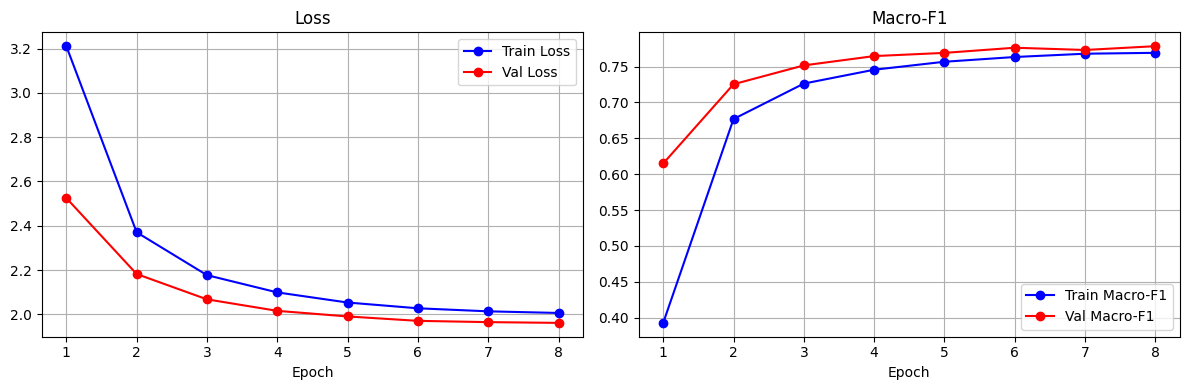

✅ Saved training_curves.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

hist_path = f"{CONFIG['model_dir']}/training_history.csv"
hist = pd.read_csv(hist_path)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(hist["epoch"], hist["train_loss"], "b-o", label="Train Loss")
ax1.plot(hist["epoch"], hist["val_loss"],   "r-o", label="Val Loss")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(True)

ax2.plot(hist["epoch"], hist["train_f1"], "b-o", label="Train Macro-F1")
ax2.plot(hist["epoch"], hist["val_f1"],   "r-o", label="Val Macro-F1")
ax2.set_title("Macro-F1"); ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved training_curves.png")


## Stage 5 — Parallel Batch Inference Benchmarking

In [ ]:
from stages.stage5_inference import benchmark_inference

predictions, inference_results = benchmark_inference(
    model, test_dataset,
    batch_sizes = [8, 16, 32, 64, 128],
    output_dir  = CONFIG["output_dir"],
    num_workers = CONFIG["num_workers"],
)

print(f"\nPredictions shape: {predictions.shape}")


  Benchmarking on 500 samples | device=cuda
  Sequential: 8.715s | 57.4 samp/s | 17.43ms/sample | VRAM=453MB
  Batch=   8 | 3.383s | 147.8 samp/s | Speedup=2.58x | VRAM=531MB
  Batch=  16 | 3.448s | 145.0 samp/s | Speedup=2.53x | VRAM=621MB
  Batch=  32 | 3.989s | 125.4 samp/s | Speedup=2.18x | VRAM=801MB
  Batch=  64 | 4.638s | 107.8 samp/s | Speedup=1.88x | VRAM=1161MB
  Batch= 128 | 6.111s | 81.8 samp/s | Speedup=1.43x | VRAM=1881MB

  Best batch: 8 (147.8 samp/s)
  Running full test-set inference (batch=8)...

Predictions shape: (7905,)


### Inference Throughput Chart

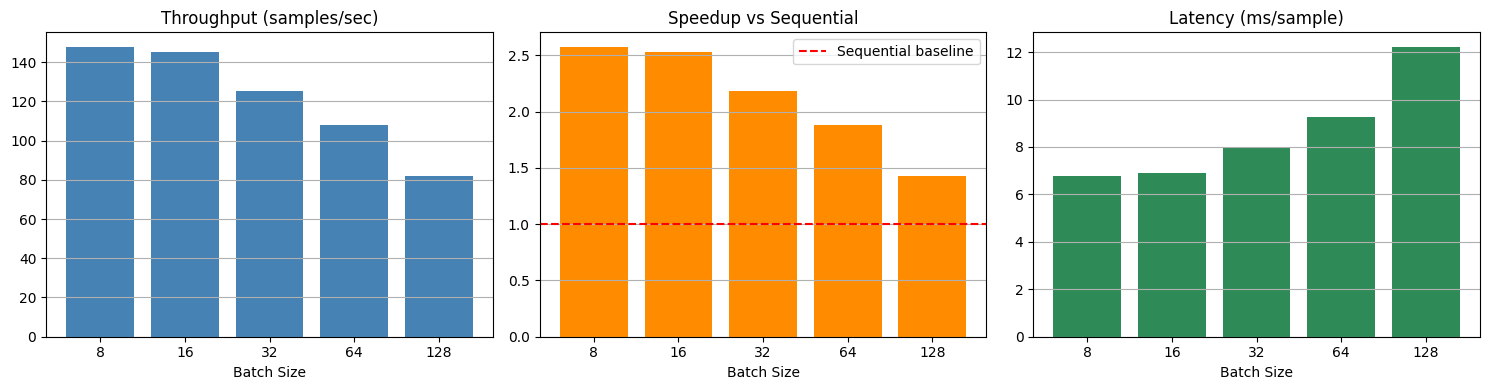

✅ Saved inference_benchmark.png


In [ ]:
import pandas as pd, matplotlib.pyplot as plt

df_inf = pd.read_csv(f"{CONFIG['output_dir']}/benchmark_inference.csv")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(df_inf["batch_size"].astype(str), df_inf["throughput_sps"], color="steelblue")
axes[0].set_title("Throughput (samples/sec)"); axes[0].set_xlabel("Batch Size"); axes[0].grid(axis="y")

axes[1].bar(df_inf["batch_size"].astype(str), df_inf["speedup"], color="darkorange")
axes[1].axhline(1.0, color="red", linestyle="--", label="Sequential baseline")
axes[1].set_title("Speedup vs Sequential"); axes[1].set_xlabel("Batch Size")
axes[1].legend(); axes[1].grid(axis="y")

axes[2].bar(df_inf["batch_size"].astype(str), df_inf["latency_ms"], color="seagreen")
axes[2].set_title("Latency (ms/sample)"); axes[2].set_xlabel("Batch Size"); axes[2].grid(axis="y")

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/inference_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved inference_benchmark.png")


## Stage 6 — Safety-Aware Evaluation

In [ ]:
# ── Optional Ablation: Symmetric Loss Baseline ────────────────────────────
# Run this AFTER the main training to get the comparison numbers for your paper
# It trains a second model with equal class weights [1,1,1,1] for ~2 epochs

from stages.stage4_train import train_model as train_model_ablation

print("Running symmetric-loss ablation (2 epochs)...")
model_abl, _ = train_model_ablation(
    train_dataset, val_dataset,
    model_dir      = CONFIG["model_dir"],
    epochs         = 2,
    batch_size     = CONFIG["batch_size"],
    lr             = CONFIG["lr"],
    use_lora       = CONFIG["use_lora"],
    skip_train     = False,
    num_workers    = CONFIG["num_workers"],
    symmetric_loss = True,   # ← ablation: equal weights
)
print("\nAblation training complete!")

# Quick inference on primary test set for ablation
from stages.stage5_inference import _full_inference
import torch
device = torch.device("cuda")
from stages.stage3_tokenize import MentalHealthDataset
abl_preds = _full_inference(model_abl, test_dataset, device, 32, 2)

import json
from sklearn.metrics import f1_score, accuracy_score
from stages.stage6_evaluate import _fnr, _rs_f1, CLASS_NAMES
labels_arr = df_test["label"].values
abl_macro_f1 = f1_score(labels_arr, abl_preds, average="macro", zero_division=0)
abl_rs_f1    = _rs_f1(labels_arr, abl_preds)
abl_hr_fnr   = (_fnr(labels_arr, abl_preds, 2) + _fnr(labels_arr, abl_preds, 3)) / 2
abl_summary  = {"macro_f1": round(float(abl_macro_f1),4),
                "risk_sensitive_f1": round(float(abl_rs_f1),4),
                "avg_high_risk_fnr": round(float(abl_hr_fnr),4)}
with open(f"{CONFIG['output_dir']}/evaluation_summary_ablation.json","w") as f:
    json.dump(abl_summary, f, indent=2)
print(f"  Ablation Macro-F1: {abl_macro_f1:.4f} | RS-F1: {abl_rs_f1:.4f} | HR-FNR: {abl_hr_fnr:.4f}")


Running symmetric-loss ablation (2 epochs)...
  Device: cuda | AMP: cuda
  Loss     : SYMMETRIC (ablation)
  Weights  : {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0}
  LoRA rank: 16 | Dropout: 0.2 | Label smoothing: off


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertModel were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  LoRA rank=16: 24 layers | Trainable: 589,824/110,072,064 (0.54%)
  Training: max_epochs=2, batch=32, lr=1e-05, patience=3


/content/pmhrd/stages/stage4_train.py:137: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scaler.step(opt); scaler.update(); sched.step()


  Ep 1/2 | TrLoss=0.9186 TrF1=0.5343 | VlLoss=0.6684 VlF1=0.6494 | 858.3s
    ✓ Best model saved (Val F1=0.6494)
  Ep 2/2 | TrLoss=0.6485 TrF1=0.6703 | VlLoss=0.6221 VlF1=0.6793 | 854.4s
    ✓ Best model saved (Val F1=0.6793)

  Best Val Macro-F1: 0.6793

✅ Ablation training complete!
✅ All stage files written!
  Ablation Macro-F1: 0.6843 | RS-F1: 0.5880 | HR-FNR: 0.5135


In [ ]:
from stages.stage6_evaluate import (
    safety_aware_evaluation, secondary_evaluation, ablation_comparison
)

# Primary 4-class evaluation
summary = safety_aware_evaluation(
    predictions       = predictions,
    labels            = df_test["label"].values,
    inference_results = inference_results,
    output_dir        = CONFIG["output_dir"],
)

# Secondary binary evaluation on DS3
from stages.stage5_inference import _full_inference
import torch
device = torch.device("cuda")
bin_preds = _full_inference(model, test_binary_dataset, device, 32, 2)
secondary_evaluation(bin_preds, df_test_binary["label"].values, CONFIG["output_dir"])

# Ablation comparison (prints table if ablation was run)
ablation_comparison(CONFIG["output_dir"])



  ── Standard Metrics ──────────────────────────────────────────
  Accuracy : 0.7961
  Macro-F1 : 0.7760
    Class 0 (No Risk                       ): F1=0.9021
    Class 1 (Mild Depression               ): F1=0.7047
    Class 2 (Mod/Severe Depression         ): F1=0.8091
    Class 3 (Self-Harm/Suicidal            ): F1=0.6881

  Confusion Matrix (rows=true, cols=pred):
                 No Risk    Mild Dep    Mod/Seve    Self-Har
  No Risk           2626         122         216          54
  Mild Depress        78        1317         110         585
  Mod/Severe D        74          92        1335          78
  Self-Harm/Su        26         117          60        1015

                       precision    recall  f1-score   support

              No Risk       0.94      0.87      0.90      3018
      Mild Depression       0.80      0.63      0.70      2090
Mod/Severe Depression       0.78      0.85      0.81      1579
   Self-Harm/Suicidal       0.59      0.83      0.69      1218

   

### Final Results Dashboard

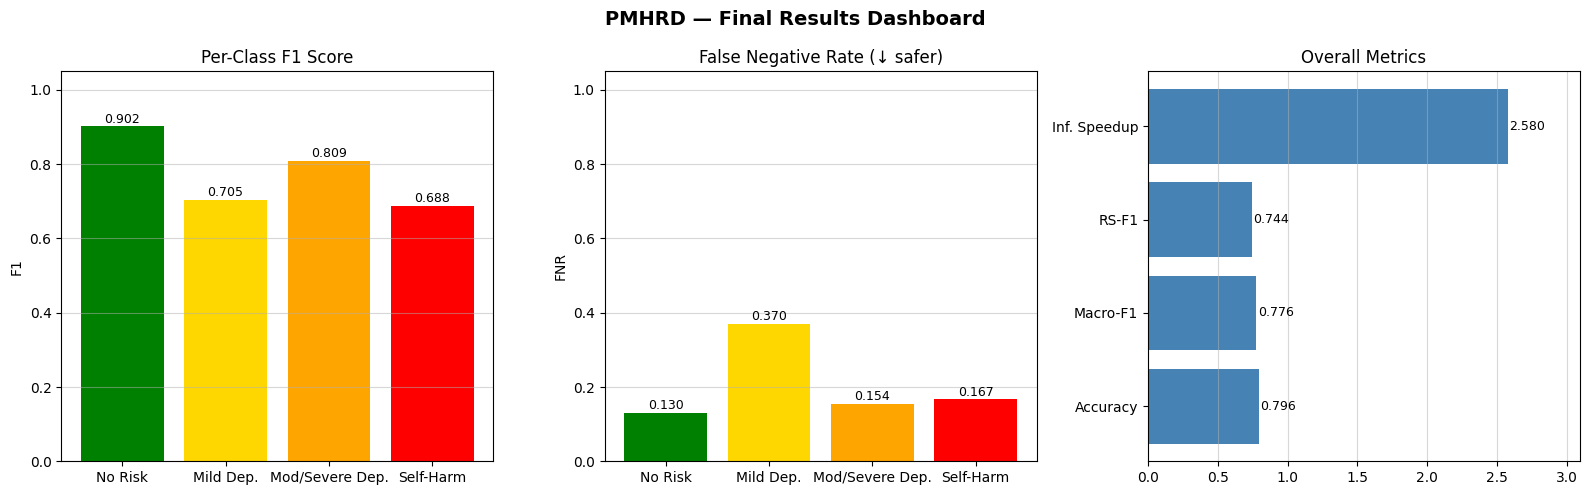


FINAL RESULTS SUMMARY
  Accuracy          : 0.7961
  Macro-F1          : 0.7760
  Risk-Sensitive F1 : 0.7436
  High-Risk FNR     : 0.1606
  Inference Speedup : 2.58x


In [ ]:
import json, matplotlib.pyplot as plt
import numpy as np

with open(f"{CONFIG['output_dir']}/evaluation_summary.json") as f:
    summary = json.load(f)

CLASS_NAMES = ["No Risk", "Mild Dep.", "Mod/Severe Dep.", "Self-Harm"]
f1_vals  = [summary["per_class_f1"][k]       for k in summary["per_class_f1"]]
fnr_vals = [summary["false_negative_rate"][k] for k in summary["false_negative_rate"]]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("PMHRD — Final Results Dashboard", fontsize=14, fontweight="bold")

# Per-class F1
colors = ["green","gold","orange","red"]
bars = axes[0].bar(CLASS_NAMES, f1_vals, color=colors)
axes[0].set_ylim(0, 1.05); axes[0].set_title("Per-Class F1 Score")
axes[0].set_ylabel("F1"); axes[0].grid(axis="y", alpha=0.5)
for bar, v in zip(bars, f1_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.01, f"{v:.3f}", ha="center", fontsize=9)

# FNR (lower = safer)
bars2 = axes[1].bar(CLASS_NAMES, fnr_vals, color=colors)
axes[1].set_ylim(0, 1.05); axes[1].set_title("False Negative Rate (↓ safer)")
axes[1].set_ylabel("FNR"); axes[1].grid(axis="y", alpha=0.5)
for bar, v in zip(bars2, fnr_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.01, f"{v:.3f}", ha="center", fontsize=9)

# Summary metrics
metrics = {
    "Accuracy": summary["accuracy"],
    "Macro-F1": summary["macro_f1"],
    "RS-F1":    summary["risk_sensitive_f1"],
    "Inf. Speedup": summary["inference_speedup"],
}
axes[2].barh(list(metrics.keys()), list(metrics.values()), color="steelblue")
axes[2].set_xlim(0, max(metrics.values())*1.2)
axes[2].set_title("Overall Metrics"); axes[2].grid(axis="x", alpha=0.5)
for i, (k, v) in enumerate(metrics.items()):
    axes[2].text(v+0.01, i, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/final_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n" + "="*50)
print("FINAL RESULTS SUMMARY")
print("="*50)
print(f"  Accuracy          : {summary['accuracy']:.4f}")
print(f"  Macro-F1          : {summary['macro_f1']:.4f}")
print(f"  Risk-Sensitive F1 : {summary['risk_sensitive_f1']:.4f}")
print(f"  High-Risk FNR     : {summary['avg_high_risk_fnr']:.4f}")
print(f"  Inference Speedup : {summary['inference_speedup']:.2f}x")
print("="*50)


## Step 7 — Download Results

In [ ]:
import shutil
from google.colab import files

# Zip the outputs folder
shutil.make_archive("pmhrd_outputs", "zip", "pmhrd/outputs")
files.download("pmhrd_outputs.zip")
print("Downloaded pmhrd_outputs.zip")
print("\nContents:")
import os
for f in sorted(os.listdir("pmhrd/outputs")):
    size = os.path.getsize(f"pmhrd/outputs/{f}")
    print(f"  {f} ({size/1024:.1f} KB)")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded pmhrd_outputs.zip

Contents:
  benchmark_inference.csv (0.3 KB)
  benchmark_preprocessing.csv (0.1 KB)
  benchmark_tokenization.csv (0.1 KB)
  ds3_secondary_eval.csv (0.1 KB)
  evaluation_summary.json (0.5 KB)
  evaluation_summary_ablation.json (0.1 KB)
  final_dashboard.png (72.6 KB)
  inference_benchmark.png (49.0 KB)
  per_class_results.csv (0.2 KB)
  predictions.csv (260.4 KB)
  training_curves.png (71.6 KB)
